# Nama : I Made Bimantoro Mastra
# Assignment : Day 13 Data Manipulation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder

# Set pengaturan agar data tidak terpotong saat ditampilkan
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## A. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

Load Dataset

In [3]:
#load dataset "California" pada file project dengan mengisi bagian yang kosong
df_california = pd.read_csv('/content/sample_data/california_dataset.csv')

#tampilkan lima baris awal dataset yang telah di-load dengan mengisi bagian yang kosong

df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
len(df_california)

20640

MedInc/ Median Income = Median pendapatan penduduk di walayah tersebut dengan satuannya puluhan ribu dolar. Misal 8.3252 artinya sekitar $83.252.

HouseAge = Umur rumah di wilayah itu, dalam tahun. Misal 41.0 = rumah-rumah di situ rata-rata udah berumur 41 tahun.

AveRooms = Rata-rata jumlah ruangan per rumah tangga di wilayah itu.

AveBedrms = Rata-rata jumlah kamar tidur per rumah tangga di wilayah itu.

Population = Jumlah total penduduk yang tinggal di wilayah itu.

AveOccup = Rata-rata jumlah penghuni per rumah tangga (berapa orang tinggal dalam 1 rumah).

Latitude = Koordinat lintang lokasi wilayah tersebut.

Longitude = Koordinat bujur lokasi wilayah tersebut.

house_price = Median harga rumah di wilayah itu (satuannya ratusan ribu dolar, jadi 4.526 artinya sekitar $452.600).

#### Split Data
Lakukan splitting data terlebih dahulu ke dalam data train dan data test.

**NOTES:**
* train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10)
* Data train di-handling outliernya, tetapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning secara objektif.

In [5]:
# Lakukan splitting data di sini
X_train, X_test = train_test_split(df_california, test_size=0.2, random_state=0)

In [6]:
len(X_train)

16512

In [7]:
len(X_test)

4128

**INSIGHT**

Data train seperti data yang sudah pernah di train sedangkan data test seperti data yang akan mau ditest apakah model benar sudah paham.  

karna ingin split data 80:20 jadi memakai 0,2 artinya 20% data test dan sisa data train 80% .

### Assignment 1.a :
1. Lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom: `['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup']` di dataset California.
2. Lakukan visualisasi ini secara terpisah untuk tujuan Machine Learning dan juga untuk melihat pola data.

Untuk tujuan Machine Learning

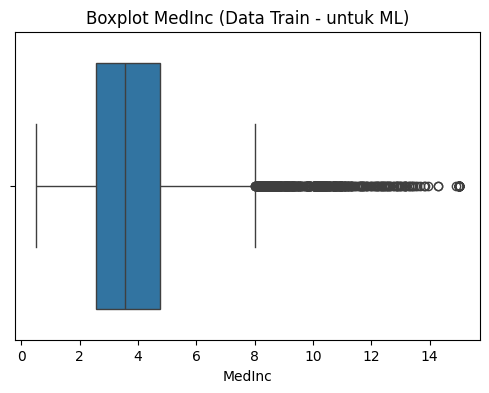

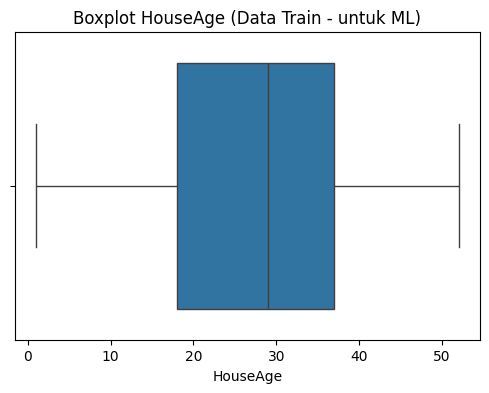

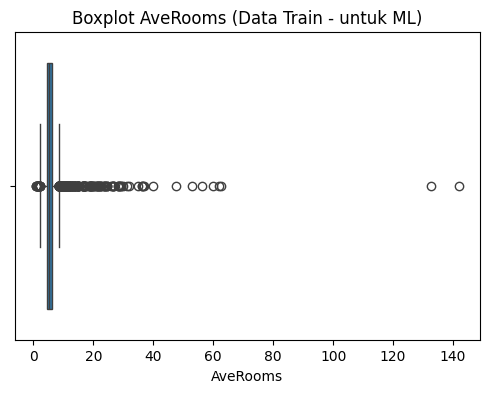

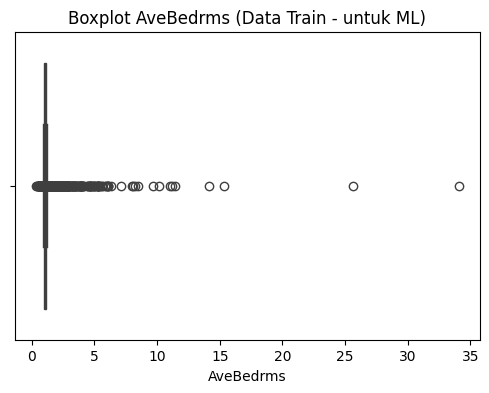

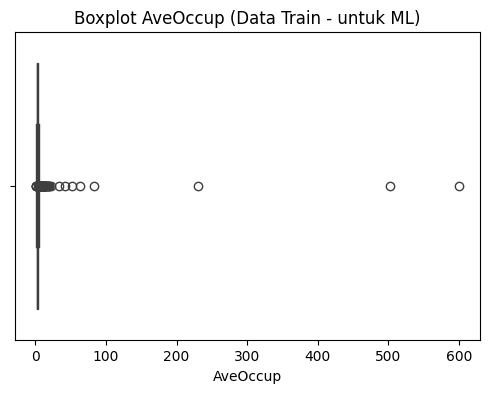

In [8]:
# Tuliskan kode untuk memuat plot distribusi data dan melihat outliers pada setiap kolom yang dicek untuk kebutuhan Machine Learning
cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for col in cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=X_train[col])
    plt.title(f'Boxplot {col} (Data Train - untuk ML)')
    plt.show()

In [9]:
X_train.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'house_price'],
      dtype='object')

**INSIGHT**

Dari boxplot data train, kolom `AveOccup` dan `Avebedrms` punya titik-titik outlier paling banyak dan paling ekstrem karna titiknya jauh di luar box. Kolom `HouseAge` paling bersih, hampir tidak ada outlier.

Untuk tujuan Melihat Pola Data

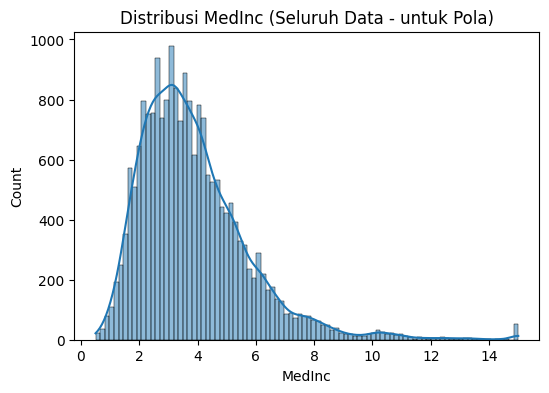

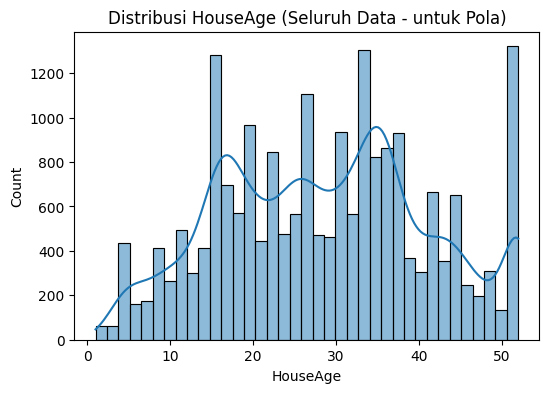

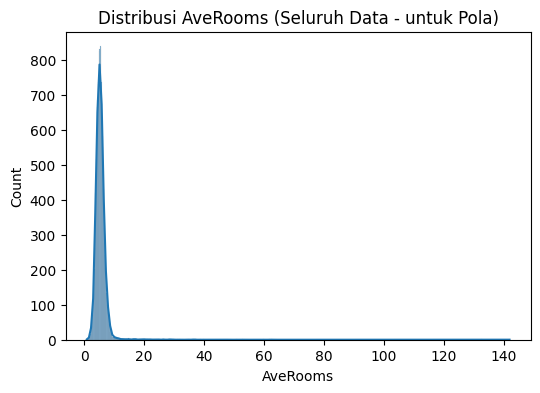

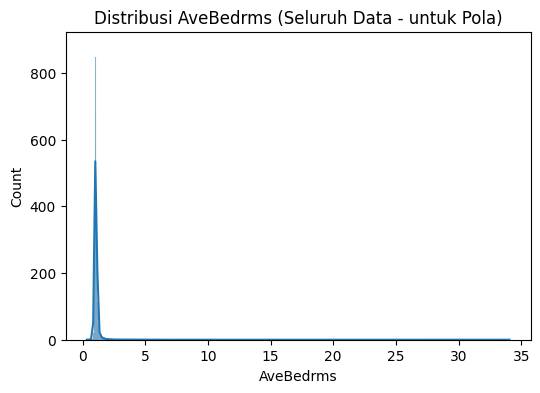

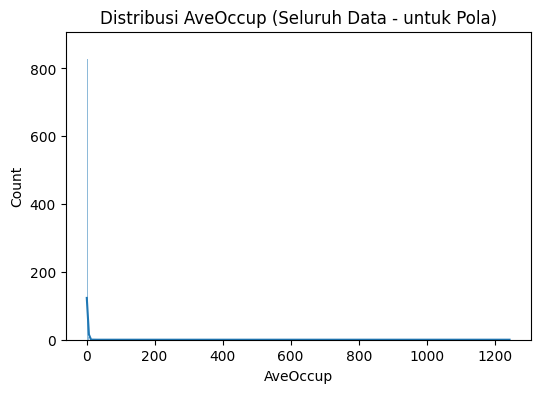

In [10]:
# Tuliskan kode untuk memuat plot distribusi data dan melihat outliers pada setiap kolom yang dicek untuk kebutuhan melihat pola data
for col in cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_california[col], kde=True)
    plt.title(f'Distribusi {col} (Seluruh Data - untuk Pola)')
    plt.show()

Tuliskan Insight untuk soal nomor 1.a:

**TULISKAN INSIGHT DI SINI**

Dari histogram seluruh data, terlihat kolom `MedInc` dan `AveRooms` bentuknya miring ke kanan/ Right Skewed. Sebagian besar rumah punya pendapatan/jumlah kamar yang relatif kecil sampai sedang, tetapi ada sedikit rumah dengan nilai sangat tinggi sampai menarik ekornya ke kanan. Mayoritas rumah di dataset ini kelas menengah, tetapi ada rumah yang sangat mewah sebagai pengecualian. Histogram `AveOccup` menunjukkan distribusi yang sangat ekstrim, hampir seluruh data mengelompok di rentang 0-10, namun karena adanya titik outlier hingga nilai 1243, sumbu-x menjadi sangat panjang sehingga bentuk distribusi aslinya sulit terbaca.

### Assignment 1.b :
1. Lakukan handling outlier, pilih 1 kolom saja yang di-handling dengan IQR setelah mengecek distribusinya.
2. Cek distribusinya kembali setelah di-handling untuk tujuan Machine Learning dan melihat pola data.

Melakukan outlier handling menggunakan IQR

In [11]:
X_train[cols].describe()

,MedInc,HouseAge,AveRooms,AveBedrms,AveOccup
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.876298,28.619065,5.432607,1.096174,3.030518
std,1.906783,12.600999,2.523415,0.489529,6.441340
min,0.499900,1.000000,0.846154,0.333333,0.750000
25%,2.566625,18.000000,4.447644,1.005760,2.428016
50%,3.548500,29.000000,5.234243,1.048720,2.817937
75%,4.747575,37.000000,6.059008,1.100000,3.283243
max,15.000100,52.000000,141.909091,34.066667,599.714286


Kolom yang diuji `AveOccup` karna dilihat dari max min nya mempunyai jenjang yang sangat jauh dibanding yang lain.

`Q1` = 2.43

`Q3` = 3.28

`IQR` = 3.28 - 2.43 = 0.853   (IQR = Q3 - Q1)

`Batas bawah` = 2.43 - (1.5 × 0.853) = 2.43 - 1.28 = 1.15

`Batas atas`  = 3.28 + (1.5 × 0.853) = 3.28 + 1.28 = 4.56

In [12]:
col = 'AveOccup'

# Mencari Quartil 1 25% dan Quartil 3 75%.
Q1 = X_train[col].quantile(0.25)
Q3 = X_train[col].quantile(0.75)
IQR = Q3 - Q1

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)


Q1: 2.4280164642247106
Q3: 3.2832432200480604
IQR: 0.8552267558233497


In [13]:
# Mencari batas bawah dan batas atas.
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Cek berapa banyak data yang outlier.
outlier = (X_train[col] < batas_bawah) | (X_train[col] > batas_atas) # Menggunakan True/ False untuk mencari jumlah outlier, jika dibawah batas bawah atau jika diatas batas atas.
print('Outlier sebelum handling:', outlier.sum())                              # Menjumlahkan semua True.

Outlier sebelum handling: 552


In [14]:
# Handling Outlier dengan clip.
X_train[col] = X_train[col].clip(lower=batas_bawah, upper=batas_atas)

outlier_sesudah = (X_train[col] < batas_bawah) | (X_train[col] > batas_atas) # Menghitung Outlier setelah di handling.
print('Outlier sesudah handling:', outlier_sesudah.sum())

Outlier sesudah handling: 0


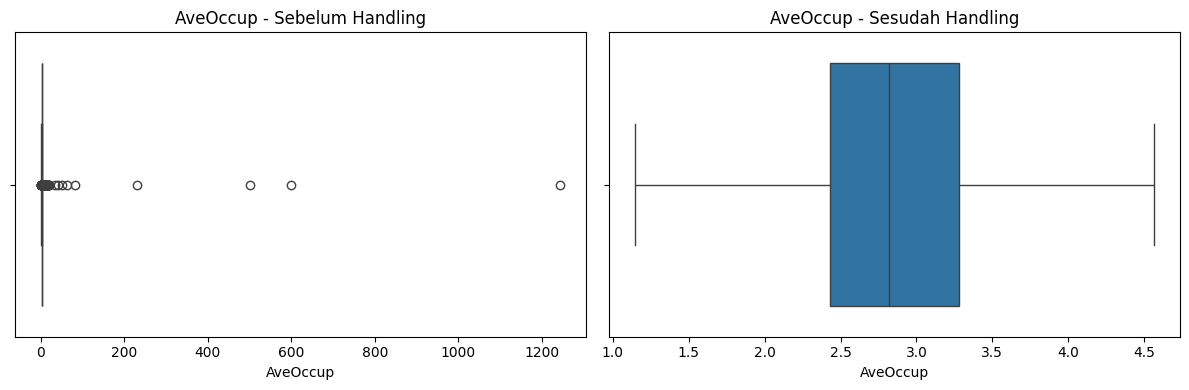

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))     # Bikin 1 baris, 2 kolom grafik berdampingan

# Boxplot SEBELUM handling (pakai data asli yang belum di-clip)
sns.boxplot(x=df_california[col], ax=axes[0])       # x=df_california seluruh data awal yang belum di apa2in, axes 0 posisi grafik di kiri
axes[0].set_title(f'{col} - Sebelum Handling')

# Boxplot SESUDAH handling (X_train yang sudah di-clip)
sns.boxplot(x=X_train[col], ax=axes[1])             # # x=x_train data yang sudah di clip, axes 0 posisi grafik di kiri
axes[1].set_title(f'{col} - Sesudah Handling')

plt.tight_layout()
plt.show()

**INSIGHT**

Menggunakan metode IQR pada kolom AveOccup (rata-rata jumlah penghuni per rumah tangga), ditemukan 582 dari 16.512 baris data train (3.52%) merupakan outlier, dengan batas wajar antara 1.15 - 4.56 orang/rumah. Mayoritas outlier (575 dari 582, atau 98.8%) berada di sisi atas yaitu rumah tangga dengan kepadatan penghuni jauh melebihi batas wajar, dengan nilai maksimum mencapai 1243.33 orang/rumah. Selisih dari mean (3.10) dan median (2.82) yang cukup jauh menunjukkan rata-rata tertarik ke atas akibat nilai-nilai ekstrem tersebut.

Alasan menggunakan `Clip`/ Capping adalah agar tidak kehilangan informasi di kolom lain. Daripada `Drop` akan menghapus 582 baris lebih baik menggunakan Capping/ `Clip` karna untuk nilai yang berada di luar batas bawah/atas "diratakan" menjadi sama dengan batas tersebut.

Menampilkan distribusi setiap kolom untuk tujuan Machine Learning

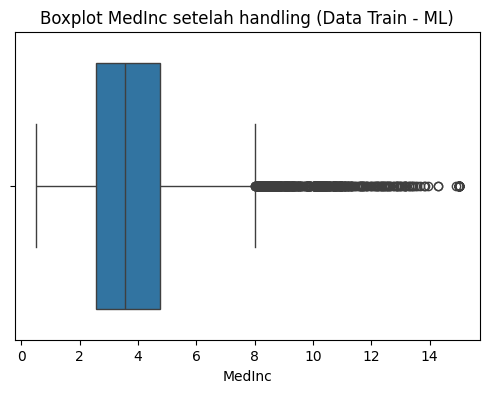

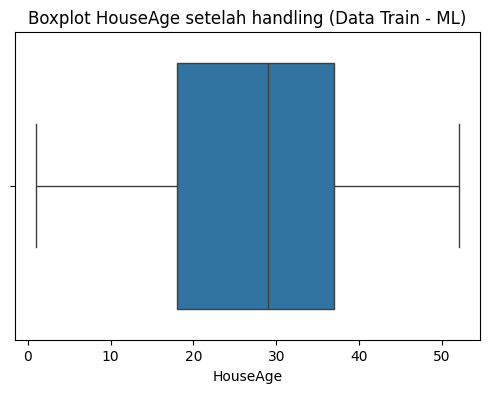

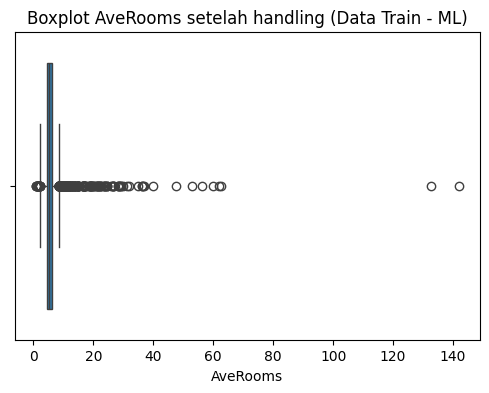

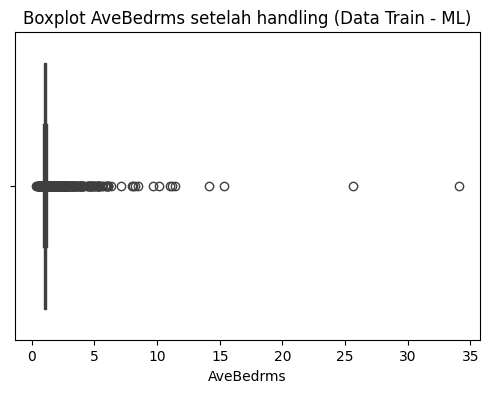

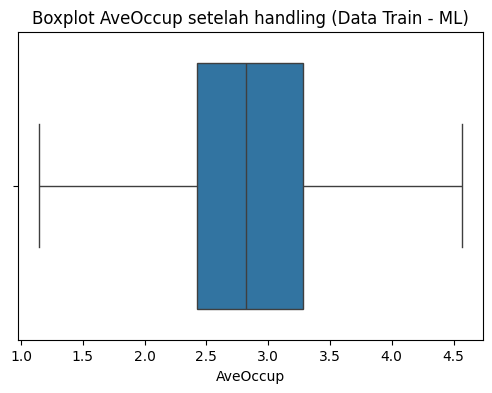

In [16]:
# Lakukan loop untuk mengecek dan menampilkan distribusi tiap kolom
for c in cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=X_train[c])
    plt.title(f'Boxplot {c} setelah handling (Data Train - ML)')
    plt.show()

**INSIGHT**

Boxplot AveOccup yang sebelumnya menunjukkan banyak titik ekstrem hingga 1200+ kini menjadi rapat pada rentang 1-4.6, dan histogramnya yang sebelumnya "gepeng" (karena sumbu-x dipaksa menampung nilai hingga 1243) kini berbentuk lebih mendekati distribusi normal dan mudah dibaca. Sementara itu, keempat kolom lain (MedInc, HouseAge, AveRooms, AveBedrms) tidak mengalami perubahan distribusi dibanding hasil pengecekan di 1.a, karena handling pada tahap ini memang difokuskan hanya pada satu kolom (AveOccup).

Menampilkan distribusi kolom setelah handling untuk tujuan Melihat Pola Data

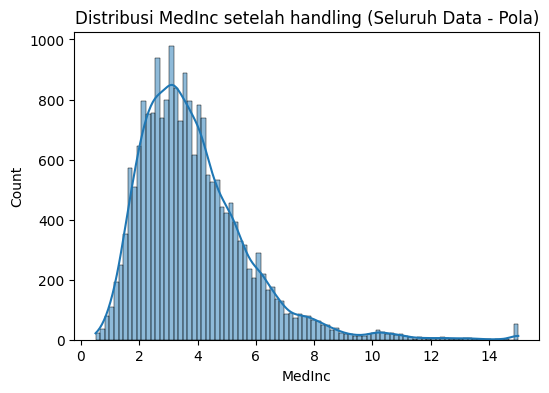

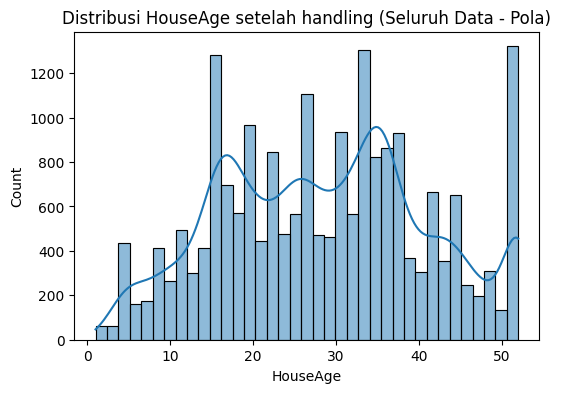

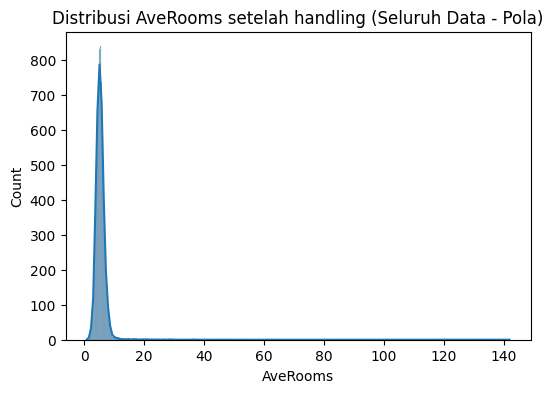

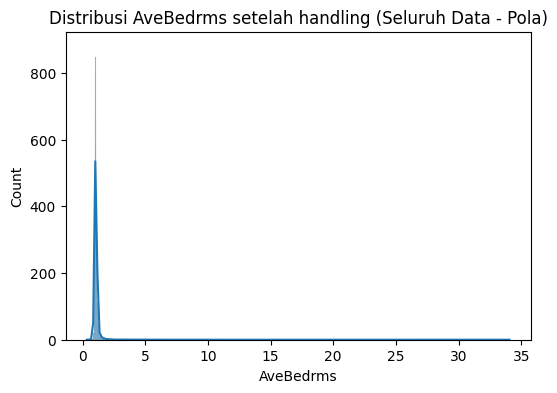

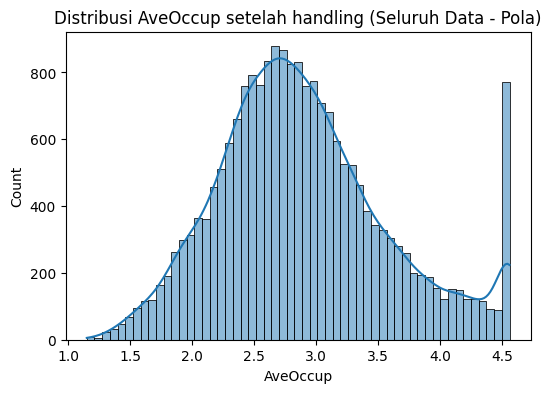

In [17]:
# Lakukan loop untuk mengecek dan menampilkan distribusi tiap kolom

Q1 = df_california[col].quantile(0.25)    # Hitung Q1 dan Q3 langsung dari df_california
Q3 = df_california[col].quantile(0.75)
IQR = Q3 - Q1                              # Hitung IQR dan pagar batas wajar dari df_california
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

df_california[col] = df_california[col].clip(lower=batas_bawah, upper=batas_atas) # .clip() langsung ditimpa ke df_california, bukan ke df_pattern. Kolom AveOccup di df_california sekarang permanen berubah (outlier-nya udah diratain).

for c in cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_california[c], kde=True)
    plt.title(f'Distribusi {c} setelah handling (Seluruh Data - Pola)')
    plt.show()

Tuliskan Insight untuk soal nomor 1.b:

**TULISKAN INSIGHT DI SINI**

`AveOccup` pada seluruh data (df_california, 20.640 baris) menunjukan perubahan signifikan setelah dihandling menggunakan metode `IQR` (batas wajar 1.15 - 4.56 orang/rumah). Histogram yang sebelumnya sangat "gepeng" ke kiri sehingga terlihat sangat kecil akibat sumbu-x yang terpaksa memuat nilai ekstrem hingga 1243 orang/rumah menjadi jauh lebih mudah dibaca, dengan sebaran data terkonsentrasi wajar di rentang 1 hingga 4.6, mendekati bentuk distribusi normal. Sementara itu, keempat kolom lain (`MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`) tetap menunjukkan pola distribusi yang sama karena proses handling pada tahap ini secara khusus difokuskan hanya pada kolom `AveOccup`.

Setelah melihat pola data secara umum, hasil ini memberikan gambaran yang lebih representatif mengenai kepadatan hunian rumah tangga di **California**. menunjukkan bahwa mayoritas wilayah memiliki rata-rata 1-5 penghuni per rumah tangga tanpa anomali data (misalnya wilayah dengan kepadatan hunian sangat tinggi seperti asrama atau apartemen padat).

## B. Missing Value Handling
Missing Value merupakan nilai yang hilang di suatu kolom. Namun tidak hanya sebatas itu, nilai yang tidak sesuai/anomali yang muncul di dalam suatu kolom tertentu juga bisa dianggap sebagai missing value (misal tipe kolom kategorikal tapi isinya berupa angka, atau sebaliknya).

#### Aturan missing value handling:
1. Jika tipe datanya **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier).
2. Jika tipe datanya **kategorik / object / string** -> handling menggunakan **mode / modus**.

#### Load Dataset Company

In [18]:
#load dataset "company.csv" pada file project dengan mengisi bagian yang kosong
df_company = pd.read_csv('/content/sample_data/company.csv')


#tampilkan lima baris awal dataset yang telah di-load dengan mengisi bagian yang kosong
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,NaN,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


In [19]:
len(df_company)

672

#### Split Data Company
Lakukan splitting data terlebih dahulu ke dalam data train dan data test sebelum melakukan handling missing value.

In [20]:
from sklearn.model_selection import train_test_split
# lakukan splitting data terlebih dahulu ke dalam data train dan data test

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

# train : test = 80:20
X_train_company, X_test_company = train_test_split(df_company, test_size=0.2, random_state=0) # random_state kunci acakan agar hasilnya sama

In [21]:
len(X_train_company)

537

In [22]:
len(X_test_company)

135

### Assignment 2. Missing Value Handling :
1. Cek persentase missing value hanya pada kolom `Headquarters` di dataset company. Cek jenis missing valuenya apakah ada atau tidak?
2. Tentukan apakah kolom tersebut layak di-drop atau tidak (Gunakan syarat drop kolom jika missing value > 20%).
3. Jika tidak di-drop, lakukan handling dengan metode yang tepat (median atau modus).
4. Terapkan secara terpisah untuk tujuan Machine Learning dan melihat pola data.

In [23]:
# Cek apakah ada NaN
print('Jumlah NaN:', X_train_company['Headquarters'].isna().sum())  # .isna() cek tiap baris pakah ini NaN beneran kosong.

# Cek isi unik kolom Headquarters, siapa tau ada nilai missinput yang sebenarnya missing value tersembunyi
print(X_train_company['Headquarters'].value_counts().head(10))      # .value_counts() ngitung berapa kali tiap nilai unik muncul, .head(10) ambil 10 teratas.

Jumlah NaN: 0
Headquarters
San Francisco, CA            26
-1                           25
New York, NY                 24
Chicago, IL                  18
Boston, MA                   17
Reston, VA                   13
Westminster, CO              11
Cambridge, United Kingdom     9
Mc Lean, VA                   8
Denver, CO                    7
Name: count, dtype: int64


In [24]:
jumlah_missing = (X_train_company['Headquarters'] == '-1').sum()  # Cek tiap baris apakah isinya persis '-1' (True/False), .sum() jumlahkan yang True
persen_missing = jumlah_missing / len(X_train_company) * 100      # len(X_train_company) = total baris data train (sekitar 537-an). 25 / 537 * 100 = 4.66%.

print(f'Jumlah missing value (-1): {jumlah_missing}')
print(f'Persentase missing value: {persen_missing:.2f}%')         # :.2f menampilkan cuma 2 angka di belakang koma.

Jumlah missing value (-1): 25
Persentase missing value: 4.66%


Untuk tujuan Machine Learning

In [25]:
X_train_company['Headquarters'].value_counts().head()

,count
Headquarters,
"San Francisco, CA",26
-1,25
"New York, NY",24
"Chicago, IL",18
"Boston, MA",17


In [26]:
# Menentukan apakah kolom layak di-drop (missing value > 20%) menggunakan if/ else.
if persen_missing > 20:
    print('Kolom di-drop, karena missing value > 20%')
else:
    print('Kolom tidak di-drop, karena missing value <= 20%')

# Jika tidak di-drop, lakukan handling dengan metode yang tepat (median atau modus).
# Ubah '-1' jadi NaN dulu biar bisa diproses fungsi pandas dengan benar, karna disini -1 salah input.
X_train_company['Headquarters'] = X_train_company['Headquarters'].replace('-1', pd.NA)  # .replace mengubah -1 yang ada di kolom headquarters menjadi NaN

# Hitung modus (nilai paling sering muncul)
modus_headquarters = X_train_company['Headquarters'].mode()[0]  # .mode()[0] untuk cari nilai kategori paling sering muncul.
print('Modus Headquarters:', modus_headquarters)

# Isi nilai kosong dengan modus.
X_train_company['Headquarters'] = X_train_company['Headquarters'].fillna(modus_headquarters)  # .fillna untuk isi semua baris kosong dengan nilai modus.

# Verifikasi: pastikan sudah tidak ada missing value lagi.
print('Sisa missing value (-1) setelah handling:', (X_train_company['Headquarters'] == '-1').sum())
print('Sisa NaN setelah handling:', X_train_company['Headquarters'].isna().sum())

Kolom tidak di-drop, karena missing value <= 20%
Modus Headquarters: San Francisco, CA
Sisa missing value (-1) setelah handling: 0
Sisa NaN setelah handling: 0


Untuk tujuan Melihat Pola Data

In [27]:
# 1. Cek jumlah dan persentase missing value (pakai df_company).
jumlah_missing_p = (df_company['Headquarters'] == '-1').sum()
persen_missing_p = jumlah_missing_p / len(df_company) * 100

print(f'Jumlah missing value (-1): {jumlah_missing_p}')
print(f'Persentase missing value: {persen_missing_p:.2f}%')

Jumlah missing value (-1): 31
Persentase missing value: 4.61%


In [28]:
# Menentukan apakah kolom layak di-drop (missing value > 20%) menggunakan if/else.
if persen_missing_p > 20:
    print('Kolom di-drop, karena missing value > 20%')
else:
    print('Kolom tidak di-drop, karena missing value <= 20%')

Kolom tidak di-drop, karena missing value <= 20%


In [29]:
# Ubah '-1' jadi NaN dulu biar bisa diproses fungsi pandas dengan benar.
df_company['Headquarters'] = df_company['Headquarters'].replace('-1', pd.NA)

# Hitung modus (nilai paling sering muncul).
modus_headquarters_p = df_company['Headquarters'].mode()[0]
print('Modus Headquarters:', modus_headquarters_p)

# Isi nilai kosong dengan modus.
df_company['Headquarters'] = df_company['Headquarters'].fillna(modus_headquarters_p)

# Verifikasi: pastikan sudah tidak ada missing value lagi.
print('Sisa missing value (-1) setelah handling:', (df_company['Headquarters'] == '-1').sum())
print('Sisa NaN setelah handling:', df_company['Headquarters'].isna().sum())

Modus Headquarters: New York, NY
Sisa missing value (-1) setelah handling: 0
Sisa NaN setelah handling: 0


Tuliskan Insight untuk soal nomor 2:

**TULISKAN INSIGHT DI SINI**

Missing value tidak selalu NaN melainkan bisa juga yang salah input seperti yang ada di kolom Headquarter yaitu missing valuenya -1 yang jelas bukan merupakan alamat kantor pusat yang valid.Ini menegaskan bahwa deteksi missing value tidak cukup hanya mengandalkan .isna(), tetapi juga perlu memeriksa isi unik kolom (.value_counts()) untuk menemukan anomali serupa. baik x_train_company dan df_company persentase missing valuenya berkisar 4.6% sehingga tidak harus didrop melainkan diganti menjadi modus karna Headquarters bertipe data kategorikal. Kedua itu memiliki modus yang berbeda dikarenakan proses train-test split membagi data secara acak, sehingga sebaran frekuensi kategori pada subset 80% data train bisa sedikit berbeda dari keseluruhan populasi data.

Untuk tujuan **Machine Learning**, penggunaan modus dari `data train` saja penting untuk mencegah data leakage karna model tidak boleh melihat informasi dari `data test` saat proses imputasi. Sementara untuk tujuan melihat **pola data**, penggunaan modus dari keseluruhan data memberikan gambaran yang lebih representatif mengenai kota mana yang paling dominan sebagai lokasi kantor pusat perusahaan dalam dataset ini secara keseluruhan.

## C. Encoding
Definisi: Mengubah tipe data kategorikal menjadi numerikal dengan pendekatan aturan encoding tertentu untuk persiapan sebelum masuk ke tahap permodelan Machine Learning.

#### Load Dataset Telco Customer Churn

In [30]:
 #load dataset "Telco-Customer-Churn.csv" pada file project dengan mengisi bagian yang kosong
df_churn = pd.read_csv('/content/sample_data/Telco-Customer-Churn.csv')


#tampilkan lima baris awal dataset yang telah di-load dengan mengisi bagian yang kosong
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
#### Split Data Churn
## Lakukan splitting data terlebih dahulu sebelum melakukan encoding.
X_train_churn, X_test_churn = train_test_split(df_churn, test_size=0.2, random_state=0)

In [33]:
len(X_train_churn)

5634

In [34]:
len(X_test_churn)

1409

### Assignment 3.a Label Encoder:
1. Lakukan Label Encoding pada kolom `Partner` dan `Dependents`.
2. Pilih kolom-kolom lain yang terindikasi bersifat Data Ordinal.
3. Bersihkan nilai yang tidak sesuai: Ubah kategori "No internet service" menjadi "No", lalu validasi hasilnya menggunakan `value_counts()`.
4. Implementasikan secara terpisah untuk tujuan Machine Learning dan melihat pola data.

In [35]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder  # otomatis ngubah teks kategori jadi angka (misal 'No'→0, 'Yes'→1).
le = LabelEncoder()

### untuk tujuan machine learning

In [36]:
# Ubah No Internet Service menjadi "No"
kolom_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in kolom_internet:
    X_train_churn[col] = X_train_churn[col].replace('No internet service', 'No')

print(X_train_churn['OnlineSecurity'].value_counts())

OnlineSecurity
No     4015
Yes    1619
Name: count, dtype: int64


In [37]:
# Label Encoding kolom Partner.
# Partner yang isinya 'Yes'/'No' diubah jadi angka 1/0.
X_train_churn['Partner'] = le.fit_transform(X_train_churn['Partner'])

print(X_train_churn['Partner'].unique())
print(X_train_churn['Partner'].value_counts())

[1 0]
Partner
0    2907
1    2727
Name: count, dtype: int64


In [38]:
# Label Encoding kolom Dependents.
X_train_churn['Dependents'] = le.fit_transform(X_train_churn['Dependents'])

print(X_train_churn['Dependents'].unique())
print(X_train_churn['Dependents'].value_counts())

[0 1]
Dependents
0    3949
1    1685
Name: count, dtype: int64


In [39]:
# Label Encoding kolom Contract.
# Contract (Month-to-month, One year, Two year) diubah jadi angka, karena punya urutan/tingkatan yang jelas (ordinal).
X_train_churn['Contract'] = le.fit_transform(X_train_churn['Contract'])

print(X_train_churn['Contract'].unique())
print(X_train_churn['Contract'].value_counts())

[2 0 1]
Contract
0    3113
2    1336
1    1185
Name: count, dtype: int64


### Untuk tujuan Melihat Pola Data

In [40]:
# Buat salinan data
df_churn_pattern = df_churn.copy()

In [41]:
# Bersihkan No internet service menjadi "No".
for col in kolom_internet:
    df_churn_pattern[col] = df_churn_pattern[col].replace('No internet service', 'No')

print(df_churn_pattern['OnlineSecurity'].value_counts())

OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64


In [42]:
# Label Encoding Partner.
le_p = LabelEncoder()

df_churn_pattern['Partner'] = le_p.fit_transform(df_churn_pattern['Partner'])
print(df_churn_pattern['Partner'].unique())
print(df_churn_pattern['Partner'].value_counts())

[1 0]
Partner
0    3641
1    3402
Name: count, dtype: int64


In [43]:
# Label Encoding Dependents.
df_churn_pattern['Dependents'] = le_p.fit_transform(df_churn_pattern['Dependents'])
print(df_churn_pattern['Dependents'].unique())
print(df_churn_pattern['Dependents'].value_counts())

[0 1]
Dependents
0    4933
1    2110
Name: count, dtype: int64


In [44]:
# Label Encoding Contract.
df_churn_pattern['Contract'] = le_p.fit_transform(df_churn_pattern['Contract'])
print(df_churn_pattern['Contract'].unique())
print(df_churn_pattern['Contract'].value_counts())

[0 1 2]
Contract
0    3875
2    1695
1    1473
Name: count, dtype: int64


Tuliskan Insight untuk soal nomor 3.a:

**TULISKAN INSIGHT DI SINI**
Label Encoding diterapkan pada 3 kolom: Partner, Dependents, dan Contract yang dipilih sebagai kolom tambahan bersifat ordinal karena memiliki tingkatan komitmen pelanggan yang jelas. Hasil encoding menunjukkan urutan angka yang sesuai dengan logika ordinal tersebut (0, 1, 2), karena kebetulan urutan alfabetis kategorinya sejalan dengan urutan tingkatannya, sebuah hal yang tetap perlu diverifikasi manual, mengingat LabelEncoder secara default mengurutkan kategori berdasarkan alfabet, bukan berdasarkan makna ordinalnya.

Sebelum encoding, ditemukan bahwa enam kolom terkait layanan internet memiliki kategori "No internet service" yang sama saja dengan "No" karna mereka sama2 tidak memakai internet. Kategori diubah menjadi "No" untuk menggampangkan sebelum encoding dilakukan.

Ada perbedaan hasil antara data train dan keseluruhan data, contoh pada `Partner` proporsi "Yes" pada data train adalah 48.4% (2.727 dari 5.634), sedangkan pada keseluruhan data sedikit lebih tinggi yaitu 48.3% (3.402 dari 7.043).

### Assignment 3.b Mean Encoding:
1. Lakukan proses Mean Encoding pada kolom `InternetService`.
2. Terapkan secara terpisah untuk kebutuhan Machine Learning dan melihat pola data.

In [45]:
# Buat fungsi Mean Encoding yang bisa dipakai ulang untuk kedua tujuan
def mean_encoding(df, kolom_kategori, kolom_target):
    # Ubah target jadi angka (Yes=1, No=0), simpan sementara di kolom baru
    df['Churn_numeric'] = df[kolom_target].map({'Yes': 1, 'No': 0})

    # Hitung rata-rata target untuk tiap kategori
    mapping = df.groupby(kolom_kategori)['Churn_numeric'].mean()

    # Ganti kategori dengan hasil rata-ratanya
    df[kolom_kategori] = df[kolom_kategori].map(mapping)

    return df, mapping

### untuk tujuan machine learning

In [46]:
X_train_churn, mean_map_ml = mean_encoding(X_train_churn, 'InternetService', 'Churn')
print(mean_map_ml)

InternetService
DSL            0.187435
Fiber optic    0.419952
No             0.078560
Name: Churn_numeric, dtype: float64


### Untuk tujuan Melihat Pola Data

In [47]:
df_churn_pattern = df_churn.copy()
df_churn_pattern, mean_map_pattern = mean_encoding(df_churn_pattern, 'InternetService', 'Churn')
print(mean_map_pattern)

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn_numeric, dtype: float64


Tuliskan Insight untuk soal nomor 3.b:

**TULISKAN INSIGHT DI SINI**
Mean Encoding diterapkan pada kolom InternetService dengan menghitung rata-rata Churn untuk setiap kategori layanan internet. Hasilnya menunjukkan pola yang jelas dan bermakna secara bisnis:
*   Fiber optic memiliki tingkat churn tertinggi (~42%), jauh di atas kategori lainnya
*   DSL memiliki tingkat churn sedang (~18-19%)
*   Pelanggan tanpa layanan internet memiliki tingkat churn terendah (~7-8%)

Berbeda dengan Label Encoding yang hanya memberi angka penanda tanpa makna (0, 1, 2), Mean Encoding menghasilkan angka yang langsung merepresentasikan hubungan kategori dengan target. Secara bisnis, temuan ini mengindikasikan bahwa pelanggan Fiber optic merupakan segmen berisiko tinggi yang mungkin memerlukan perhatian khusus, sementara pelanggan tanpa layanan internet cenderung paling loyal.





# BAGIAN 2: DATA INTEGRATION & MANIPULATION

## D. Data Integration & Advanced Manipulation
Pada bagian ini, Anda diminta menggabungkan beberapa sumber data terpisah menjadi satu kesatuan data yang utuh, lalu melakukan eksplorasi manipulasi data lanjut untuk melihat tren dan pola data.

#### Load Dataset Utama & Tambahan (Supermarket Sales)

In [48]:
# Load Dataset Utama & Tambahan dengan mengisi bagian yang kosong
df_raw = pd.read_csv('/content/sample_data/supermarket_sales.csv')

In [49]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [50]:

df_supermarket = df_raw.iloc[:950].drop(columns=['City'])                    # Dataset Utama (Supermarket Sales).
# .iloc[:950] ambil baris ke-0 sampai ke-949 (950 baris pertama) dari data asli.
# .drop(columns=['City']) membuang kolom City, supaya nanti bisa dilatih digabungkan lagi pakai merge().

df_product_info = df_raw[['Branch', 'City']].drop_duplicates().reset_index(drop=True)  # Dataset Tambahan (Informasi produk & branch).
# df_raw[['Branch', 'City']] ambil cuma 2 kolom itu dari data asli.
# .drop_duplicates() untuk buang baris yang kombinasi Branch-City-nya berulang, sisain yang unik aja.
# .reset_index(drop=True) untuk merapikan lagi nomor index-nya jadi urut.

df_new_sales = df_raw.iloc[950:].reset_index(drop=True)                      # Dataset Tambahan (Data penjualan baru untuk di-append).
# .iloc[950:] untuk mengambil baris ke-950 sampai baris terakhir (50 baris sisanya), disimulasikan sebagai "transaksi baru" yang belum tergabung ke data utama.
# .reset_index(drop=True) untuk merapikan lagi nomor index-nya jadi urut.

# Tampilkan 5 baris awal dari masing-masing dataset untuk memahami strukturnya
print('df_supermarket:')
print(df_supermarket.head())

print('\ndf_product_info:')       # \n kasih jarak.
print(df_product_info.head())

print('\ndf_new_sales:')
print(df_new_sales.head())

df_supermarket:
    Invoice ID Branch Customer type  Gender            Product line  \
0  750-67-8428      A        Member  Female       Health and beauty   
1  226-31-3081      C        Normal  Female  Electronic accessories   
2  631-41-3108      A        Normal    Male      Home and lifestyle   
3  123-19-1176      A        Member    Male       Health and beauty   
4  373-73-7910      A        Normal    Male       Sports and travel   

   Unit price  Quantity   Tax 5%     Total       Date   Time      Payment  \
0       74.69         7  26.1415  548.9715   1/5/2019  13:08      Ewallet   
1       15.28         5   3.8200   80.2200   3/8/2019  10:29         Cash   
2       46.33         7  16.2155  340.5255   3/3/2019  13:23  Credit card   
3       58.22         8  23.2880  489.0480  1/27/2019  20:33      Ewallet   
4       86.31         7  30.2085  634.3785   2/8/2019  10:37      Ewallet   

     cogs  gross margin percentage  gross income  Rating  
0  522.83                 4.761905 

### Assignment 4.a Joining & Merging Data:
Analisislah kaitan data penjualan dengan detail informasi produk dan cabang. Gabungkan `df_product_info` ke dalam dataset utama `df_supermarket` menggunakan fungsi gabungan kolom yang tepat (`merge` atau `join`).

In [51]:
# Tuliskan kode untuk melakukan Merging/Joining data di sini
df_merged = df_supermarket.merge(df_product_info, on='Branch', how='left')
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               950 non-null    object 
 1   Branch                   950 non-null    object 
 2   Customer type            950 non-null    object 
 3   Gender                   950 non-null    object 
 4   Product line             950 non-null    object 
 5   Unit price               950 non-null    float64
 6   Quantity                 950 non-null    int64  
 7   Tax 5%                   950 non-null    float64
 8   Total                    950 non-null    float64
 9   Date                     950 non-null    object 
 10  Time                     950 non-null    object 
 11  Payment                  950 non-null    object 
 12  cogs                     950 non-null    float64
 13  gross margin percentage  950 non-null    float64
 14  gross income             9

### Assignment 4.b Appending Data:
Gabungkan data transaksi penjualan baru (`df_new_sales`) ke dalam data penjualan utama Anda yang sudah digabung sebelumnya agar baris data bertambah banyak menggunakan metode penggabungan baris (`concat` atau `append`).

In [52]:
# Tuliskan kode untuk melakukan Appending data di sini
df_full = pd.concat([df_merged, df_new_sales], ignore_index=True)
# pd.concat([...]) menumpuk dua DataFrame secara vertikal (menambah baris, bukan kolom), karena keduanya sudah punya struktur kolom yang sama.
# ignore_index=True membuat index hasil gabungan dibuat ulang dari 0 sampai 999, bukan mempertahankan index asli masing-masing
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   Customer type            1000 non-null   object 
 3   Gender                   1000 non-null   object 
 4   Product line             1000 non-null   object 
 5   Unit price               1000 non-null   float64
 6   Quantity                 1000 non-null   int64  
 7   Tax 5%                   1000 non-null   float64
 8   Total                    1000 non-null   float64
 9   Date                     1000 non-null   object 
 10  Time                     1000 non-null   object 
 11  Payment                  1000 non-null   object 
 12  cogs                     1000 non-null   float64
 13  gross margin percentage  1000 non-null   float64
 14  gross income             

### Assignment 4.c Filtering & Sorting Data:
1. Buatlah 1 pertanyaan analisis mandiri yang memerlukan penyaringan kondisi tertentu (`Filtering`), lalu jalankan kodenya untuk menjawab pertanyaan tersebut dan melihat karakteristik datanya.
2. Buatlah analisis mengenai pola urutan total penjualan per bulan, gunakan fungsi pengurutan (`Sorting`) untuk melihat performa tertinggi hingga terendah.

In [53]:
# 1. Kode untuk Filtering Data berdasarkan pertanyaan analisis Anda
df_filtered = df_full[(df_full['Payment'] == 'Ewallet') & (df_full['Total'] > 500)]
# df_full['Payment'] == 'Ewallet' membuat kondisi boolean (True/False) untuk tiap baris: apakah pembayarannya Ewallet.
df_filtered.head()

,Invoice ID,Branch,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,City
0,750-67-8428,A,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1,Yangon
4,373-73-7910,A,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3,Yangon
5,699-14-3026,C,Normal,Male,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,18:30,Ewallet,597.73,4.761905,29.8865,4.1,Naypyitaw
7,315-22-5665,C,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38,Ewallet,735.60,4.761905,36.7800,8.0,Naypyitaw
37,272-65-1806,A,Normal,Female,Electronic accessories,60.88,9,27.3960,575.3160,1/15/2019,17:17,Ewallet,547.92,4.761905,27.3960,4.7,Yangon


In [54]:
# 2. Kode untuk Sorting Data total penjualan
df_full['Date'] = pd.to_datetime(df_full['Date'])
df_full['Month'] = df_full['Date'].dt.month_name()

monthly_sales = df_full.groupby('Month')['Total'].sum().reset_index()
monthly_sales_sorted = monthly_sales.sort_values(by='Total', ascending=False)
monthly_sales_sorted

,Month,Total
1,January,116291.868
2,March,109455.507
0,February,97219.374


**INSIGHT**

Hasil filter (Ewallet & Total > 500) menghasilkan 75 dari 1000 transaksi (7,5%). Rata-rata belanja kelompok ini Rp691,6 ribu, jauh di atas rata-rata belanja keseluruhan (Rp322,97 ribu). Cash justru sedikit lebih tinggi (326,2) dibanding Ewallet (318,8) dan Credit card (324,0), meski jumlah pengguna ketiganya cukup merata (Ewallet 345, Cash 344, Credit card 311). Jadi metode pembayaran tidak terlalu memengaruhi besar-kecilnya nilai transaksi pelanggan besar maupun kecil tersebar rata di ketiga metode.

Januari adalah bulan dengan penjualan tertinggi dan Februari terendah, selisihnya cukup besar sekitar 19 juta antara bulan tertinggi dan terendah. Karena data hanya mencakup 3 bulan (dataset per kuartal), pola ini bisa mengindikasikan awal tahun (mungkin efek promo/tahun baru) lebih ramai dibanding pertengahan kuartal, lalu sedikit naik lagi di Maret.

### Assignment 4.d Grouping, Aggregasi, & Datetime Operations:
1. Gunakan operasi `datetime` untuk mengekstrak komponen waktu (seperti bulan atau nama hari) dari kolom tanggal yang tersedia.
2. Lakukan pengelompokan (`Grouping` & `Aggregasi`) minimal pada 1 kolom kategorikal dan lebih dari 1 kolom numerikal untuk menghasilkan rangkuman nilai agar bisa melihat pola penjualan secara jelas.

In [62]:
# 1. Operasi Datetime untuk memproses kolom waktu
df_full['Day_Name'] = df_full['Date'].dt.day_name()
df_full.head()

,Invoice ID,Branch,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,City,Month,Day_Name
0,750-67-8428,A,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1,Yangon,January,Saturday
1,226-31-3081,C,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6,Naypyitaw,March,Friday
2,631-41-3108,A,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4,Yangon,March,Sunday
3,123-19-1176,A,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4,Yangon,January,Sunday
4,373-73-7910,A,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3,Yangon,February,Friday


In [63]:
df_full['Day_Name'].value_counts()

,count
Day_Name,
Saturday,164
Tuesday,158
Wednesday,143
Friday,139
Thursday,138
Sunday,133
Monday,125


In [56]:
# 2. Operasi Grouping dan Aggregasi data
df_group = df_full.groupby(['Branch', 'Product line']).agg(
    Total_Penjualan=('Total', 'sum'),
    Total_Qty=('Quantity', 'sum'),
    Avg_Rating=('Rating', 'mean')
).reset_index()
df_group

,Branch,Product line,Total_Penjualan,Total_Qty,Avg_Rating
0,A,Electronic accessories,18317.1135,322,6.911667
1,A,Fashion accessories,16332.5085,263,6.878431
2,A,Food and beverages,17163.1005,313,7.253448
3,A,Health and beauty,12597.7530,257,6.900000
4,A,Home and lifestyle,22417.1955,371,6.930769
5,A,Sports and travel,19372.6995,333,7.257627
6,B,Electronic accessories,17051.4435,316,7.116364
7,B,Fashion accessories,16413.3165,297,6.722581
8,B,Food and beverages,15214.8885,270,6.994000
9,B,Health and beauty,19980.6600,320,7.100000


**INSIGHT**

Berdasarkan hari penjualan tertinggi terjadi di hari Sabtu (56,1 juta) dan Selasa (51,5 juta), sedangkan Senin paling sepi (37,9 juta) pola khas ritel, di mana akhir pekan jadi puncak kunjungan, sementara awal minggu kerja cenderung sepi.

**Berdasarkan Branch × Product line:**
*   Kombinasi dengan penjualan tertinggi adalah Branch C – Food and beverages (23,8 juta), kemudian Branch A – Home and lifestyle (22,4 juta).
*   Dari sisi rating kepuasan, Branch C – Fashion accessories punya rating rata-rata tertinggi (7,44), sementara Branch B – Sports and travel terendah (6,51) meskipun nilai penjualannya cukup besar (19,9 juta).Volume penjualan tinggi tidak selalu berbanding lurus dengan kepuasan pelanggan, jadi ada yang harus dievaluasi lebih lanjut (misal soal layanan atau kualitas produk kategori itu di Branch B).



### Assignment 4.e Pivot & Crosstab Analysis:
1. Buatlah ringkasan tabel data menggunakan fungsi `Pivot Table` dengan memilih kombinasi kolom kategori dan numerik yang tepat untuk melihat pola hubungan antar variabel yang berguna.
2. Jalankan analisis menggunakan fungsi `Crosstab` untuk membandingkan frekuensi persebaran data antar dua variabel kategori tertentu.

In [57]:
# 1. Kode pembuatan Pivot Table
pivot_table = df_full.pivot_table(index='Branch', columns='Product line', values='Total', aggfunc='sum')

In [64]:
pivot_table

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Branch,,,,,,
A,18317.1135,16332.5085,17163.1005,12597.753,22417.1955,19372.6995
B,17051.4435,16413.3165,15214.8885,19980.660,17549.1645,19988.1990
C,18968.9745,21560.0700,23766.8550,16615.326,13895.5530,15761.9280


In [58]:
# 2. Kode pembuatan Crosstab Analysis
crosstab_result = pd.crosstab(df_full['Branch'], df_full['Customer type'])

In [65]:
crosstab_result

Customer type,Member,Normal
Branch,,
A,167,173
B,165,167
C,169,159


#### Tuliskan Insight Utama dari Hasil Proses Manipulasi Data (4.e):
**TULISKAN INSIGHT DI SINI**

**Pivot (Branch × Product line):**


*   Total penjualan per cabang cukup seimbang: A = 106,2 jt, B = 106,2 jt, C = 110,6 jt. Branch C sedikit unggul, terutama didorong kategori Food and beverages dan Fashion accessories yang jauh lebih tinggi di sana dibanding dua cabang lain.
*   Dari sisi kategori produk secara nasional, Food and beverages adalah kategori dengan total penjualan tertinggi (56,1 jt), sementara Health and beauty terendah (49,2 jt).

**Crosstab (Branch × Customer type):**

Proporsi Member vs Normal hampir seimbang di ketiga cabang (sekitar 49–52% Member). Branch C punya proporsi Member tertinggi (51,5%), sedikit lebih loyal dibanding A dan B.

**Kesimpulan :** performa antar cabang cukup merata (tidak ada yang timpang jauh), tapi Branch C sedikit menonjol dari sisi total penjualan maupun loyalitas pelanggan. Pola waktu (bulan & hari) justru menunjukkan variasi lebih jelas, seperti akhir pekan dan awal tahun adalah periode penjualan terbaik sehingga strategi promosi/stok bisa difokuskan di periode-periode itu.



## E. Feature Scaling
Proses penyetaraan skala nilai pada kolom fitur numerik agar tidak ada dominasi nilai besar saat model machine learning dilatih.

### Assignment 5. Feature Scaling:
1. Pilih minimal 4 kolom numerik yang paling tepat dari dataset hasil pengolahan terakhir Anda.
2. Terapkan metode **Standard Scaler** pada 4 kolom numerik tersebut untuk tujuan modeling/melihat pola data.
3. Terapkan metode **Min-Max Scaler** pada 4 kolom numerik tersebut untuk tujuan modeling/melihat pola data.

#### Feature Scaling: Standard Scaler

In [59]:
# Tulis kode transformasi menggunakan Standard Scaler di sini
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['Unit price', 'Quantity', 'Tax 5%', 'Rating']
scaler_std = StandardScaler()
df_scaled_std = df_full.copy()
df_scaled_std[cols_to_scale] = scaler_std.fit_transform(df_full[cols_to_scale])

In [66]:
df_scaled_std.head()

,Invoice ID,Branch,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,City,Month,Day_Name
0,750-67-8428,A,Member,Female,Health and beauty,0.718160,0.509930,0.919607,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,1.238443,Yangon,January,Saturday
1,226-31-3081,C,Normal,Female,Electronic accessories,-1.525303,-0.174540,-0.987730,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,1.529527,Naypyitaw,March,Friday
2,631-41-3108,A,Normal,Male,Home and lifestyle,-0.352781,0.509930,0.071446,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,0.248760,Yangon,March,Sunday
3,123-19-1176,A,Member,Male,Health and beauty,0.096214,0.852165,0.675780,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,0.830927,Yangon,January,Sunday
4,373-73-7910,A,Normal,Male,Sports and travel,1.156959,0.509930,1.267125,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,-0.973790,Yangon,February,Friday


#### Feature Scaling: Min-Max Scaler

In [60]:
# Tulis kode transformasi menggunakan Min-Max Scaler di sini
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler()
df_scaled_minmax = df_full.copy()
df_scaled_minmax[cols_to_scale] = scaler_minmax.fit_transform(df_full[cols_to_scale])

In [67]:
df_scaled_minmax.head()

,Invoice ID,Branch,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,City,Month,Day_Name
0,750-67-8428,A,Member,Female,Health and beauty,0.718847,0.666667,0.521616,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,0.850000,Yangon,January,Saturday
1,226-31-3081,C,Normal,Female,Electronic accessories,0.057855,0.444444,0.067387,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,0.933333,Naypyitaw,March,Friday
2,631-41-3108,A,Normal,Male,Home and lifestyle,0.403316,0.666667,0.319628,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,0.566667,Yangon,March,Sunday
3,123-19-1176,A,Member,Male,Health and beauty,0.535603,0.777778,0.463549,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,0.733333,Yangon,January,Sunday
4,373-73-7910,A,Normal,Male,Sports and travel,0.848131,0.666667,0.604377,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,0.216667,Yangon,February,Friday


#### Tuliskan Alasan Pemilihan 4 Kolom Numerik Tersebut untuk Di-scaling:
**TULISKAN ALASAN DI SINI**

Karna empat kolom ini masing-masing punya satuan dan rentang nilai yang berbeda jauh:

*   `Unit price` berkisar puluhan hingga ratusan (misal 10–100)
*   `Quantity` hanya berkisar 1–10
*   `Tax 5%` bernilai desimal kecil (hasil 5% dari subtotal)
*   `Rating` berskala tetap 1–10 tapi merepresentasikan kepuasan pelanggan, bukan nilai transaksi.

Tanpa proses scaling, kolom dengan skala nilai besar seperti `Unit price` berpotensi mendominasi perhitungan model , sehingga kolom bernilai kecil seperti `Quantity` atau `Tax 5%` dianggap kurang berpengaruh padahal informasinya sama pentingnya.

Kolom seperti `Total`, `cogs`, dan `gross income` sengaja tidak dipilih karena nilainya adalah hasil turunan langsung dari `Unit price` × `Quantity` (dan `Tax 5%`), sehingga jika ikut di-scaling bersama kolom asalnya akan menimbulkan informasi yang tumpang tindih dalam model.


# BAGIAN 3: REFLECTION QUESTION

Setelah menyelesaikan seluruh rangkaian proses pembersihan hingga manipulasi data di atas, jawablah pertanyaan refleksi berikut dengan menambahkan tulisan Anda di bawah:

1. Setelah melakukan data cleaning, apa hal paling penting yang kamu sadari tentang hubungan antara kualitas data dan kepercayaan terhadap hasil analisis atau model yang dibangun? Jelaskan contoh dampak yang kamu temukan dari data yang belum dibersihkan.

2. Dalam proses membersihkan data (misalnya menangani missing value, duplikasi, atau data tidak konsisten), keputusan mana yang menurutmu paling krusial dan mengapa? Bagaimana keputusan tersebut memengaruhi interpretasi data di tahap selanjutnya?

**JAWABAN REFLEKSI ANDA:**
1. ...
2. ...

## Thank you :)